# **SubGraphs In LangGraph** 

In [1]:
from langgraph.graph import StateGraph, START, END;
from typing import TypedDict, Annotated;
import operator;

class ParentState(TypedDict):
    raw_input: str;
    text: str;
    errors: Annotated[list[str], operator.add];
    is_valid: bool;
    final_output: str;

class ValidationState(TypedDict): # Subgraph State
    text: str;
    errors: Annotated[list[str], operator.add];
    is_valid: bool;

def check_length(state: ValidationState) -> dict:

    return {"errors": ["Too short (min 5)"]} if len(state["text"]) < 5 else {"errors": []};


def check_no_digits(state: ValidationState) -> dict:

    return {"errors": ["No numbers allowed"]} if any(c.isdigit() for c in state["text"]) else {"errors": []};


def set_validity(state: ValidationState) -> dict:

    return {"is_valid": len(state["errors"]) == 0};

In [2]:
sub = StateGraph(ValidationState);

sub.add_node("len", check_length);

sub.add_node("digits", check_no_digits);

sub.add_node("validity", set_validity);

sub.add_edge(START, "len");

sub.add_edge("len", "digits");

sub.add_edge("digits", "validity");

sub.add_edge("validity", END);

validation_subgraph = sub.compile();

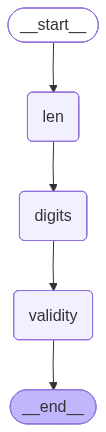

In [3]:
from IPython.display import Image, display;

display(Image(validation_subgraph.get_graph(xray=True).draw_mermaid_png()));

In [4]:
def preprocess(state: ParentState) -> dict:

    return {
        "text": state["raw_input"].strip(),
        "errors": []
    };

def handle_valid(state: ParentState) -> dict:

    return {"final_output": f"✅ Accepted: {state["text"]}"};


def handle_invalid(state: ParentState) -> dict:

    return {"final_output": f"❌ Rejected: {", ".join(state["errors"])}"};

parent = StateGraph(ParentState);

parent.add_node("preprocess", preprocess);

parent.add_node("validate", validation_subgraph); # Subgraph

parent.add_node("valid", handle_valid);

parent.add_node("invalid", handle_invalid);

parent.add_edge(START, "preprocess");

parent.add_edge("preprocess", "validate");

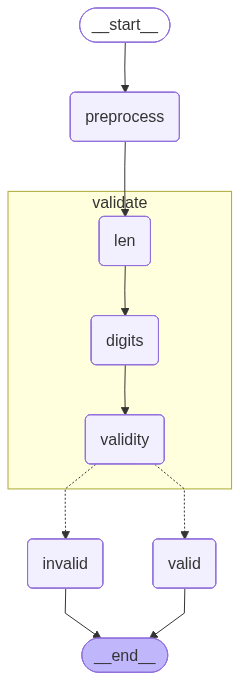

In [5]:
parent.add_conditional_edges(
    "validate",
    lambda _state: "valid" if _state["is_valid"] else "invalid",
    {
        "valid": "valid",
        "invalid": "invalid"
    }
);

parent.add_edge("valid", END);

parent.add_edge("invalid", END);

graph = parent.compile();

display(Image(graph.get_graph(xray=True).draw_mermaid_png()));

In [6]:
for inputdata in ["Hi", "Hello World", "Hello123", "  LangGraph  ", "AK47"]:

    response = graph.invoke(
        {
            "raw_input": inputdata,
            "text": "",
            "errors": [],
            "is_valid": True,
            "final_output": ""
        }
    );

    print(f"{inputdata} → {response["final_output"]}");

Hi → ❌ Rejected: Too short (min 5)
Hello World → ✅ Accepted: Hello World
Hello123 → ❌ Rejected: No numbers allowed
  LangGraph   → ✅ Accepted: LangGraph
AK47 → ❌ Rejected: Too short (min 5), No numbers allowed
